## Scientific Machine Learning 2026, Tutorial 1 part 1:
#Learning the Ising Hamiltonian using linear regression

Perimeter Scholars International 2025-2026

This is a notebook modified from Lauren Hayward's notebook by Gang Xu

**References:** Section VI.D of https://arxiv.org/abs/1803.08823, and the corresponding Notebook D from https://physics.bu.edu/~pankajm/MLnotebooks.html

### Generate the data set:<span style="color:blue"> (Play with M and N here)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn import linear_model
%matplotlib inline

np.random.seed(2026) # we usually set a random seed so whatever we do is repeatable

M = 1000  #number of samples
N = 20   #number of spins
J = 1.0  #coupling energy for generating the data

#Randomly generate the spin configurations
s = np.random.choice([-1,1], size=(M,N))

def getEnergy_nnIsing1D(s):
  return -J*np.sum(s*np.roll(s,-1,axis=1),axis=1) 
    # np.roll shifts the big M by N matrix left by one (-1) and it is applied rowwise(across columns) (axis=1)
#s*np.roll elementwise multiplication 
#np.sum (...axis=1) sum along columns for each row
H = getEnergy_nnIsing1D(s) #Labels for each configuration



### Introduce the variables X <span style="color:blue"> Fill in the paranthesis of x=np.einsum() part (c)

In [2]:
# Introduce the variable x as in part b): s_j*s_k --> x_p 
#effectively x[..., j,k]=s[...,j]*s[...,k]
#np.einsum('ij,j->i', A,x) will do the matrix multiplication \sum_jA_{ij}x_{j} sum over repeated index and -> make sure i stay unsummed
#if you have a repeated index, but does not want it to be summed over use ... to represent it everywhere
#write part c) code here using np.einsum, fill in the paranthesis

x=np.einsum("...j,...k->...jk", s, s)


#Consider only the upper triangular part of this matrix since we only want to consider k>j:
iu = np.triu_indices(x.shape[1],k=1) #k=1 means strictly above the main diagonal x has dimension (M,N,N) so x.shape[1]=N
#triu_indices produces row and column indices for the upper triangle so a 3*3 matrix will return
#[0,0,1][1,2,2] representing the pairs 0,1 0,2 1,2
print(x.shape)
x = x[:,iu[0],iu[1]]#now for each row(M) : take all the elements indexed as upper triangle above
print(x.shape) # notice that this process will change the shape of our features from a 3d array to a 2d one which is what we need 

(1000, 20, 20)
(1000, 190)


### Define a function to plot the coupling parameters $J_{jk}$ <span style="color:blue">(No need to change anything here)

In [3]:
def plot_J(w,N):
  J = np.zeros((N,N))

  #Fill in the upper triangular part with entries from w:
  iu = np.triu_indices(N,k=1)# same indices as before
  J[iu] = -1.0*w
  print(np.diag(J,k=1))#k=1 means excluding the diagonal, starts from the first super diagonal

  #Plot this matrix:
  max_Jmag = max(np.max(J),-1*np.min(J)) # find the max magnitude of J
  cmap_args=dict(vmin=min(-1.,-1*max_Jmag), vmax=max(1.,max_Jmag), cmap='PRGn')
    #used in imshow below as color mapping parameters vmin is the minimum data value for the colormap, vmax is the maximum data value for the colormap
    #ensures the colormap at least cover [-1,1]. notice it centers around 0. PRGn is from purple to green a diverging colormap

  fig, ax = plt.subplots()#create figure and axes
  im      = ax.imshow(J,**cmap_args)#imshow display a 2D array as an image, each element becomes a pixel values mapped to colors
  # it returns an AxesImage object 
  ax.set_title(r'$J_{jk}$',fontsize=18)

  divider = make_axes_locatable(ax)#make divider
  cax = divider.append_axes("right", size="5%", pad=0.1)#create a new axes on the right
  cbar=fig.colorbar(im, cax=cax)#attach colorbar to this axes

  plt.show()

### Find the parameters $J_{jk}$ using the exact solution <span style="color:blue">(both methods are given, just comment out the one not using) part(d)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


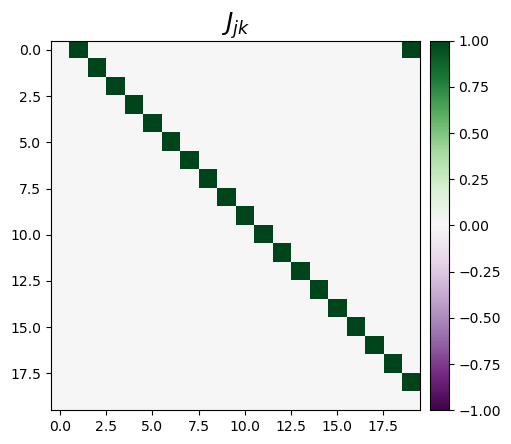

CPU times: total: 141 ms
Wall time: 162 ms


In [7]:
%%time

w_exact = np.linalg.inv(x.T.dot(x)).dot(x.T).dot(H) #the exact solution
# w_exact = linear_model.LinearRegression().fit(x, H).coef_ # the exact solution using linear model from sklearn
#print(w_exact)
plot_J(w_exact,N)

# 200 is good 
# 180 is kinda bad 

### Find the parameters $J_{jk}$ using gradient descent <span style="color:blue"> (need to code to initialize parameter part e) and remove arguments from the Regressor part g))

[0.9997785  1.00004826 0.99951555 0.9996179  0.99975727 0.99984474
 0.99935492 0.99927311 0.99937807 0.99948811 0.99974547 0.99991607
 0.99955533 0.99982256 1.00009861 0.9999844  1.00007545 0.999834
 0.99976372]


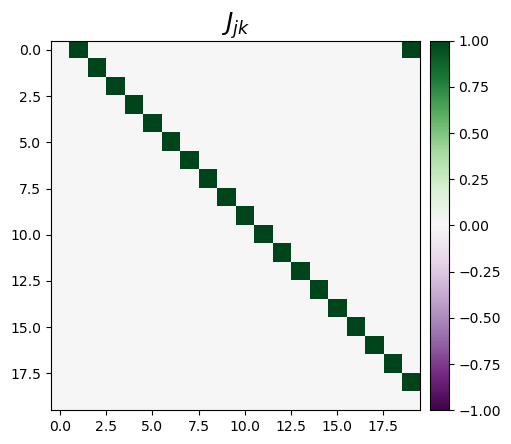

CPU times: total: 141 ms
Wall time: 148 ms


In [6]:
%%time
# student write code here initialize the w parameters randomly 
#the shape of w_init should be changing when you change M or N


w_init = np.random.uniform(0, 1, (N**2-N)//2)


#Apply gradient descent with a constant learning rate of eta0:
w_GD = linear_model.SGDRegressor().fit(x, H, coef_init=w_init).coef_
#student write code here

# change learning rate --> changes size of jumps 
# 0.01 works, 0.011 doesnt!
# 0.000001 also doesn't work, 0.00001 is kinda right 
# 100 spins make it bad, because now we have a lot of parameters and comparatively less samples 
# 50 is also kinda bad, 35 is pretty good 

plot_J(w_GD,N)

# getting rid of args is fine, default is good!  